In [21]:
import os
import sys

# Move one level up from Notebook to the project root
project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [22]:
import os

import librosa
import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from Features.mfcc import extract_mfcc
from Models.baseline_rf import train_random_forest

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [23]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

In [24]:
dataset_path = r"F:\PhD\PhD_Project\Dataset"

X = []
y = []

for root, dirs, files in os.walk(dataset_path):

    for file in tqdm(files):

        if file.endswith(".wav"):

            file_path = os.path.join(
                root,
                file
            )

            emotion_id = file.split("-")[2]

            emotion = emotion_map[emotion_id]

            features = extract_mfcc(
                file_path
            )

            X.append(features)

            y.append(emotion)

print("Total Samples:", len(X))

0it [00:00, ?it/s]
100%|██████████| 60/60 [00:01<00:00, 53.14it/s]
0it [00:00, ?it/s]
100%|██████████| 60/60 [00:02<00:00, 28.42it/s]

Total Samples: 2880


In [25]:
X = np.array(X)

y = np.array(y)

print(X.shape)

print(y.shape)

(2880, 40)
(2880,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2304, 40)
(576, 40)


In [27]:
# Train Random Forest model
model = train_random_forest(
    X_train,
    y_train
)

# Predict on test data
y_pred = model.predict(X_test)

print("Training Completed Successfully")

Training Completed Successfully


In [28]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(
        accuracy * 100,
        2
    ),
    "%"
)

Accuracy: 91.67 %


In [29]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

       angry       1.00      0.95      0.97        76
        calm       0.86      0.95      0.90        77
     disgust       0.86      0.79      0.82        77
     fearful       0.88      0.92      0.90        77
       happy       0.95      0.97      0.96        77
     neutral       0.95      1.00      0.97        38
         sad       0.97      0.84      0.90        77
   surprised       0.90      0.95      0.92        77

    accuracy                           0.92       576
   macro avg       0.92      0.92      0.92       576
weighted avg       0.92      0.92      0.92       576



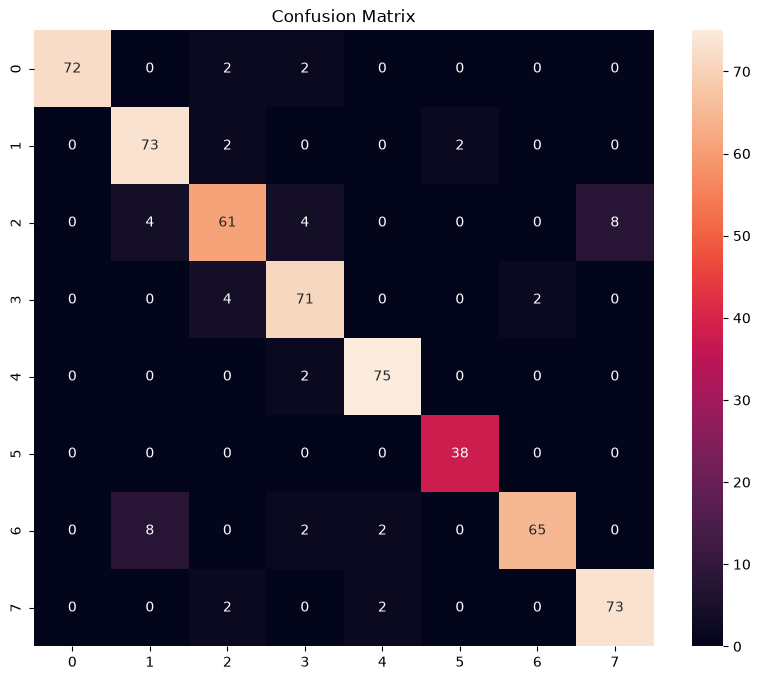

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.show()